# Data Salary Analysis:

## Part 1: Data Exploration

1. Các em thấy dataset này có bao nhiêu vấn đề? Liệt kê không giới hạn số lượng.
2. Nếu ai đó dùng dataset này nguyên trạng để phân tích lương, điều gì có thể xảy ra?
3. Vấn đề nào theo em là nghiêm trọng nhất? Tại sao?

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv('../../Data/DH_Extra/salary_survey_raw.csv')
df.head()

,timestamp,how_old_are_you,industry,job_title,additional_context_on_job_title,annual_salary,additional_monetary_comp,currency,income_context,country,us_state,city,years_of_experience_in_field,years_of_experience_overall,highest_level_of_education,gender,race
0,04/12/2021 16:11:47,45-54,Legal,Legal Counsel,NaN,"56,894",NaN,USD,NaN,NaN,NaN,Boston,21 - 30 years,21 - 30 years,College degree,Man,Black or African American
1,04/25/2021 09:28:06,25-34,Finance,Investment Analyst,NaN,"144,543","$9,839",USD,NaN,United States,Washington,NaN,8 - 10 years,8 - 10 years,College degree,Man,Multiracial
2,04/15/2021,25-34,Nonprofit,Grant Writer,NaN,"52,304.00",NaN,AUD,NaN,United States,Washington,NaN,21 - 30 years,21 - 30 years,PhD,Woman,NaN
3,04/21/2021 03:36:47,55-64,Real Estate,Real Estate Manager,NaN,"51,765",18454,AUD,NaN,United States,NaN,Los Angeles,2 - 4 years,2 - 4 years,Master's degree,Male,NaN
4,2021-04-26 03:04,35-44,Nursing,Charge Nurse,Senior level,"133,218","8,424",USD,NaN,UK,NaN,NaN,11 - 20 years,11 - 20 years,College degree,Woman,NaN


### Câu 1


Số lượng dòng trùng lặp hoàn toàn: 38

---KIỂM TRA KIỂU DỮ LIỆU---
annual_salary    str
currency         str
dtype: object

---KIỂM TRA OUTLIER (Ngoại lai)---


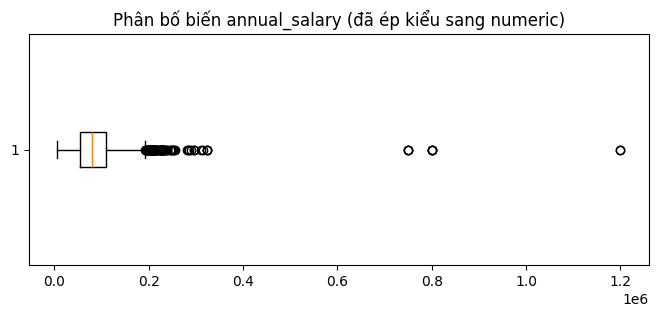


---KIỂM TRA MỨC ĐỘ NULL---
income_context                     81.035714
us_state                           64.750000
city                               55.785714
additional_monetary_comp           54.928571
additional_context_on_job_title    34.607143
dtype: float64

---KIỂM TRA INCONSISTENT DATA (Bất nhất)---
Các loại tiền tệ trong cột 'currency': <StringArray>
['USD', 'AUD', 'USD ', 'GBP', 'CAD', 'INR', 'EUR', 'usd']
Length: 8, dtype: str


In [17]:
# 1. Kiểm tra lặp dữ liệu (Duplicates)
duplicate_rows = df.duplicated().sum()
print(f"Số lượng dòng trùng lặp hoàn toàn: {duplicate_rows}")

# 2. Kiểm tra kiểu dữ liệu (Data Types) và Ngoại lai (Outliers)
print("\n---KIỂM TRA KIỂU DỮ LIỆU---")
print(df[['annual_salary', 'currency']].dtypes) # annual_salary đang là object thay vì số

# Cố gắng chuyển annual_salary sang biến số thực để vẽ boxplot phát hiện Outlier
print("\n---KIỂM TRA OUTLIER (Ngoại lai)---")
df_salary = pd.to_numeric(df['annual_salary'].astype(str).str.replace(',', ''), errors='coerce')
plt.figure(figsize=(8,3))
plt.boxplot(df_salary.dropna(), vert=False)
plt.title("Phân bố biến annual_salary (đã ép kiểu sang numeric)")
plt.show()

# 3. Kiểm tra dữ liệu thiếu (Missing value)
print("\n---KIỂM TRA MỨC ĐỘ NULL---")
missing_ratio = (df.isnull().sum() / len(df)) * 100
print(missing_ratio[missing_ratio > 0].sort_values(ascending=False).head(5)) # In top 5 cột thiếu nhiều nhất

# 4. Kiểm tra sự bất nhất trong dữ liệu danh mục (Inconsistent Data)
print("\n---KIỂM TRA INCONSISTENT DATA (Bất nhất)---")
print(f"Các loại tiền tệ trong cột 'currency': {df['currency'].unique()}")

**Dựa vào kết quả code trực quan ở trên, ta tổng hợp được các vấn đề cho Câu 1:**
1. **Dữ liệu lặp (Duplicates):** Có chứa 38 dòng dữ liệu lặp lại trùng khớp (duplicate).
2. **Sai kiểu dữ liệu (Data Type):** Các biến vốn phải là biến số như `annual_salary` lại đang bị nhận diện là chuỗi (object) do chứa các ký tự như dấu phẩy `,`.
3. **Giá trị ngoại lai (Outliers):** Sau khi ép kiểu `annual_salary` sang số, biểu đồ Boxplot phơi bày những mức lương ảo, kéo dãn rất dài về bên phải, sai lệch thực tế.
4. **Dữ liệu thiếu (Missing Values):** Tập dữ liệu thủng lỗ chỗ, `additional_context_on_job_title` và `income_context` bị Null quá lớn (lên tới >70% - 80%).
5. **Dữ liệu bất nhất (Inconsistent Data):** Dữ liệu dạng hạng mục chưa được làm sạch chuẩn. Ví dụ cột `currency` chứa cả `'USD'`, `'usd'`, `'USD '` khiến công cụ hiển thị chúng thành các nhóm tiền tệ khác biệt dù mang cùng ý nghĩa.


### Câu 2:

- **Code phân tích chết yểu (Errors):** Các hàm toán học, count aggregation (như Mean, Median) hoặc vẽ biểu đồ lương sẽ lập tức văng lỗi TypeError do không thể cộng chéo các dòng toàn string (chữ) của cột `annual_salary`.
- **Rủi ro rác dữ liệu làm bóp méo số liệu trung bình:** Trục hoành của Boxplot phía trên cho thấy sự tồn tại của Outlier (những người bỏ xa đám đông còn lại hàng trăm lần lượng lương trị giá thực). Kết quả mean() nếu đếm cả mức lương đó sẽ ra kết quả ở trên mây, không đúng giá trị lương trung bình thực tiễn của thị trường nhân sự lúc bấy giờ.

### Câu 3:

- Vấn đề nghiêm trọng nhất là: **Lỗi kiểu dữ liệu và Outliers tập trung ở cột `annual_salary`.**
- **Tại sao?** Goal bài bài này là **"Phân tích hệ thống lương"**. `annual_salary` (mức lương hàng năm) đóng vai trò sống còn – "Biến mục tiêu" (Target Feature). Những Data Features khác (như tuổi, nơi ở, giới tính, năm kinh nghiệm) hoàn toàn vô nghĩa và "phế" chức năng nếu như biến chính nhất lại không thể tính toán hay cho ra các insight sai méo trầm trọng do Outlier.

## Part 2: Data Handling Questions

1. Xác định giá trị null nào null hợp lệ,null cần điền, null cần xem xét (investigate)? Vì sao?
2. Tại sao chúng ta không fillna(mean) cho cột lương?
3. Xử lý cột 'country' (null = 8%)
4. Xử lý cột 'years_of_experience' (null = 3%) , có cách nào làm mất ít thông tin hơn?
5. Viết hàm missing_report() ngắn gọn

### C1

- **Null hợp lệ:** (Ví dụ: `additional_context`) Đây là các free-text field, là cột tuỳ chọn nên người dùng có thể bỏ trống. Không cần xử lý phần này, chỉ cần ghi chú trong report và giữ nguyên dữ liệu.
- **Null cần điền:** (Ví dụ: `how_old_are_you`) Đây có thể là biến số có phân phối lệch. Việc điền sẽ dựa vào phân phối của biến để quyết định dùng `median` hay `mode` (do robust hơn với outlier so với mean).
- **Null cần xem xét (investigate):** (Ví dụ: cột lương `annual_salary_USD` hoặc `annual_salary`) Lương thường là biến mục tiêu đo lường chính, không thể tuỳ tiện điền (sẽ làm sai bản chất dữ liệu / mô hình). Cần flag ra cột mới để theo dõi, và sau đó có thể xử lý điền bằng `median` theo từng nhóm liên quan (VD: industry + experience) để sát với thực tế nhất.

### C2

- Lương (salary) ngoài thực tế thường có phân phối lệch phải (right-skewed). Sẽ có một số ít người có mức lương cực kỳ cao (outliers).
- Phép tính giá trị trung bình (`mean`) rất nhạy cảm với các outliers, có xu hướng bị kéo lên cao đáng kể, do đó không phản ánh đúng mức thu nhập của đại đa số.
- Sử dụng trung vị (`median`) sẽ ổn định và "robust" (bền vững) hơn khi dữ liệu có outlier.

### C3

- `country` là biến phân loại (categorical/nominal).
- Có thể fill `mode` (Giá trị xuất hiện nhiều nhất) nếu đa số người tham gia khảo sát đến từ 1 quốc gia.
- Hoặc an toàn hơn có thể tạo hẳn 1 category mới bằng cách `fillna('Unknown')` / `fillna('Other')` để tránh làm nhiễu tỉ lệ của các quốc gia khác.


### C4

- Nếu xóa (drop) dòng sẽ làm mất đi các thông tin quý giá ở những cột khác trong 3% dòng này.
- **Cách giữ thông tin:** Điền bằng giá trị xuất hiện thường xuyên nhất (`mode`) vì đây có thể là biến ordinal (phân nhóm kinh nghiệm).
- Tốt hơn nữa: Có thể groupby theo cột `how_old_are_you` hoặc `industry` để `transform` và điền `mode` / `median` số năm kinh nghiệm (người cùng khoảng tuổi thường có số năm kinh nghiệm tương tự nhau).

### C5

In [18]:
def missing_report(data):
    # Tính tổng số lượng giá trị null của mỗi cột
    missing_count = data.isnull().sum()
    
    # Lọc ra các cột có giá trị null > 0
    missing_count = missing_count[missing_count > 0]
    
    # Tính tỉ lệ phần trăm null
    missing_ratio = (missing_count / len(data)) * 100
    
    # Tạo DataFrame báo cáo và sắp xếp giảm dần theo phần trăm
    report = pd.DataFrame({
        'Missing Values': missing_count,
        'Ratio (%)': missing_ratio.round(2)
    }).sort_values(by='Ratio (%)', ascending=False)
    
    return report

# Chạy thử nghiệm hàm
missing_report(df)

,Missing Values,Ratio (%)
income_context,2269,81.04
us_state,1813,64.75
city,1562,55.79
additional_monetary_comp,1538,54.93
additional_context_on_job_title,969,34.61
race,766,27.36
annual_salary,391,13.96
country,115,4.11
gender,69,2.46


## Homework

1. Hoàn thành xử lý missing + duplicate + dtype cho toàn bộ dataset
2. Viết Decision Log cho ít nhất 3 quyết định (theo mẫu hôm nay)

### Xử lý Duplicate, Dtype và Missing Values

Đầu tiên, xử lý Duplicate và định dạng kiểu dữ liệu cho `annual_salary` và `additional_monetary_comp`.

In [19]:
# 1. Xử lý Duplicate
df = df.drop_duplicates()

# 2. Xử lý Dtype cho các biến tiền tệ
df['annual_salary'] = pd.to_numeric(df['annual_salary'].astype(str).str.replace(',', ''), errors='coerce')
df['additional_monetary_comp'] = pd.to_numeric(df['additional_monetary_comp'].astype(str).str.replace(',', ''), errors='coerce')

Kế tiếp, tiến hành điền giá trị Null cho các cột. Ta sẽ thêm cột cờ (flag) cho `annual_salary` trước khi impute bằng median theo `industry`.

In [20]:
# 3. Xử lý Missing Values

# a. Tạo cờ 'salary_imputed' cho annual_salary bị thiếu
df['salary_imputed'] = df['annual_salary'].isnull()

# b. Điền missing annual_salary bằng median của từng industry
df['annual_salary'] = df.groupby('industry')['annual_salary'].transform(lambda x: x.fillna(x.median()))
# Nếu vẫn còn null (do industry đó toàn null), fill bằng global median
df['annual_salary'] = df['annual_salary'].fillna(df['annual_salary'].median())

# c. Điền 'Unknown' cho các cột categorical missing lớn
cols_to_unknown = ['income_context', 'us_state', 'city', 'additional_context_on_job_title', 'country', 'gender', 'race']
for col in cols_to_unknown:
    df[col] = df[col].fillna('Unknown')

# d. Điền 0 cho additional_monetary_comp
df['additional_monetary_comp'] = df['additional_monetary_comp'].fillna(0)

# e. Điền mode cho years_of_experience
df['years_of_experience_in_field'] = df['years_of_experience_in_field'].fillna(df['years_of_experience_in_field'].mode()[0])
df['years_of_experience_overall'] = df['years_of_experience_overall'].fillna(df['years_of_experience_overall'].mode()[0])
df['how_old_are_you'] = df['how_old_are_you'].fillna(df['how_old_are_you'].mode()[0])

# f. Kiểm tra lại mức độ missing
missing_report(df)

,Missing Values,Ratio (%)
